<a href="https://colab.research.google.com/github/MMQuants/FMI_diplomna_rabota/blob/main/UNCorrelated_datasim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates

np.random.seed(42)

In [19]:
# Брой конфигурации/решения, които искаме да анализираме
num_configurations = 200

# Генериране на НАПЪЛНО НЕКОРЕЛИРАНИ критерии (всеки се генерира независимо)
# 1. Капацитет на съхранение (MWh) - равномерно разпределение
storage_capacity = np.random.uniform(low=10, high=150, size=num_configurations)

# 2. Загуби при пренос по мрежата в летните жеги (%) - нормално разпределение
# По-високите температури увеличават съпротивлението, симулираме средно 8% загуби
transmission_losses = np.random.normal(loc=8.0, scale=2.0, size=num_configurations)

# Ограничаваме физическите граници (загубите не могат да са отрицателни)
transmission_losses = np.clip(transmission_losses, 1.0, 20.0)

# 3. Инвестиционни разходи / CAPEX (в милиони евро) - експоненциално разпределение
# Повечето конфигурации са по-евтини, но има единични много скъпи мащабни проекти
capex = np.random.exponential(scale=5.0, size=num_configurations) + 1.5

# 4. Екологичен отпечатък / Въглеродни емисии (gCO2/kWh) - равномерно разпределение
carbon_footprint = np.random.uniform(low=15, high=400,size=num_configurations)

In [20]:
# Създаване на DataFrame за визуализация и последващ анализ
df_energy = pd.DataFrame({
'Configuration_ID': [f'Config_{i}' for i in range(1,
num_configurations + 1)],
'Storage_Capacity_MWh': storage_capacity,
'Transmission_Losses_Percent': transmission_losses,
'CAPEX_Mln_Euro': capex,
'Carbon_Footprint_gCO2_kWh': carbon_footprint
})
# Проверка за корелация
print("Матрица на корелацията (стойностите около 0 означават липса на корелация):")
print(df_energy.corr(numeric_only=True))

Матрица на корелацията (стойностите около 0 означават липса на корелация):
                             Storage_Capacity_MWh  \
Storage_Capacity_MWh                     1.000000   
Transmission_Losses_Percent             -0.023758   
CAPEX_Mln_Euro                          -0.121798   
Carbon_Footprint_gCO2_kWh               -0.029983   

                             Transmission_Losses_Percent  CAPEX_Mln_Euro  \
Storage_Capacity_MWh                           -0.023758       -0.121798   
Transmission_Losses_Percent                     1.000000        0.012350   
CAPEX_Mln_Euro                                  0.012350        1.000000   
Carbon_Footprint_gCO2_kWh                       0.085427        0.024814   

                             Carbon_Footprint_gCO2_kWh  
Storage_Capacity_MWh                         -0.029983  
Transmission_Losses_Percent                   0.085427  
CAPEX_Mln_Euro                                0.024814  
Carbon_Footprint_gCO2_kWh                     1.00

In [21]:
# Показване на първите 5 генерирани конфигурации
print("\nПървите 5 конфигурации в пространството от решения:")
print(df_energy.head())


Първите 5 конфигурации в пространството от решения:
  Configuration_ID  Storage_Capacity_MWh  Transmission_Losses_Percent  \
0         Config_1             62.435617                     6.639951   
1         Config_2            143.100003                     8.464507   
2         Config_3            112.479152                     8.586145   
3         Config_4             93.812188                     6.571297   
4         Config_5             31.842610                    11.731549   

   CAPEX_Mln_Euro  Carbon_Footprint_gCO2_kWh  
0        4.260166                 240.933830  
1       13.341188                 301.994198  
2        2.089401                 181.188925  
3        4.892526                  64.118417  
4        1.557093                 124.253724  


<Figure size 1000x800 with 0 Axes>

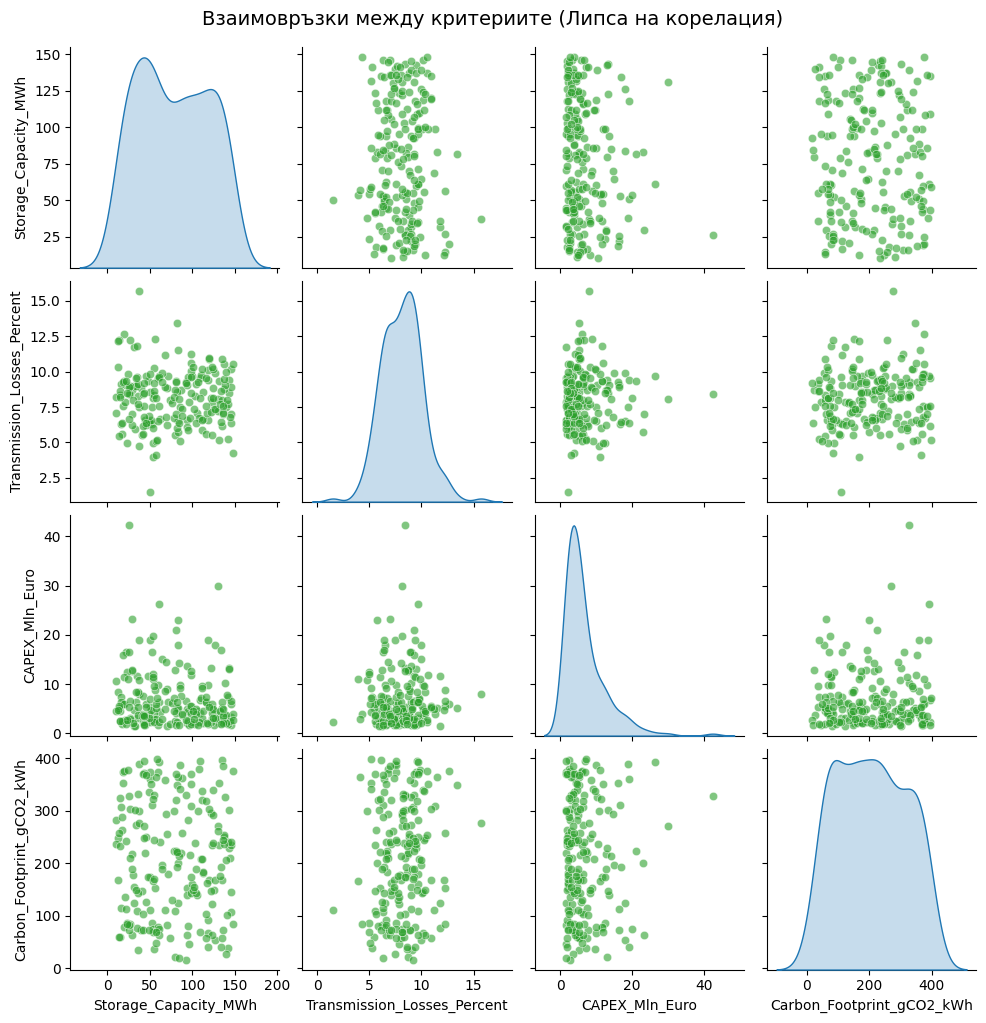

<Figure size 640x480 with 0 Axes>

In [22]:
# За по-добра визуализация в паралелните координати, ще категоризираме разходите (CAPEX)
# Това ще ни помогне да проследим как евтините vs. скъпите проекти се държат по другите критерии
df_energy['Cost_Category'] = pd.qcut(df_energy['CAPEX_Mln_Euro'],
                                     q=3,
                                     labels=['Low CAPEX', 'Medium CAPEX', 'High CAPEX'])
# ----------------------------------------------------
# ГРАФИКА 1: Pair Plot (Взаимовръзки между критериите)
# ----------------------------------------------------
plt.figure(figsize=(10, 8))
sns.pairplot(df_energy.drop(columns=['Cost_Category']),
             diag_kind='kde',
             plot_kws={'alpha': 0.6, 'color': '#2ca02c'})
plt.suptitle('Взаимовръзки между критериите (Липса на корелация)',
             y=1.02,
             fontsize=14)
plt.show()
plt.suptitle('Матрица от точкови диаграми (Липса на корелация в пространството от решения)',
             y=1.02,
             fontsize=14)
plt.show()

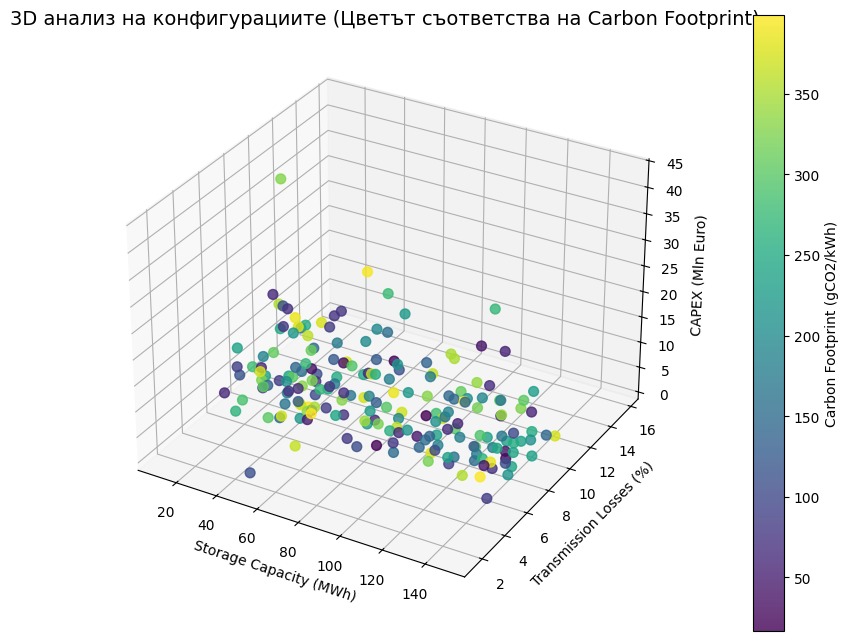

In [23]:
# ----------------------------------------------------
# ГРАФИКА 2: 3D Scatter Plot (Пространство от решения с 3 критерия)
# ----------------------------------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Прожектираме Капацитет, Загуби и CAPEX
sc = ax.scatter(
                df_energy['Storage_Capacity_MWh'],
                df_energy['Transmission_Losses_Percent'],
                df_energy['CAPEX_Mln_Euro'],
                c=df_energy['Carbon_Footprint_gCO2_kWh'], # 4-ти критерий изразен чрез цвят
                cmap='viridis',
                s=50,
                alpha=0.8 )

ax.set_xlabel('Storage Capacity (MWh)')

ax.set_ylabel('Transmission Losses (%)')

ax.set_zlabel('CAPEX (Mln Euro)')

ax.set_title('3D анализ на конфигурациите (Цветът съответства на Carbon Footprint)',
             fontsize=14)

cbar = fig.colorbar(sc,
                    ax=ax,
                    pad=0.1)
cbar.set_label('Carbon Footprint (gCO2/kWh)')
plt.show()

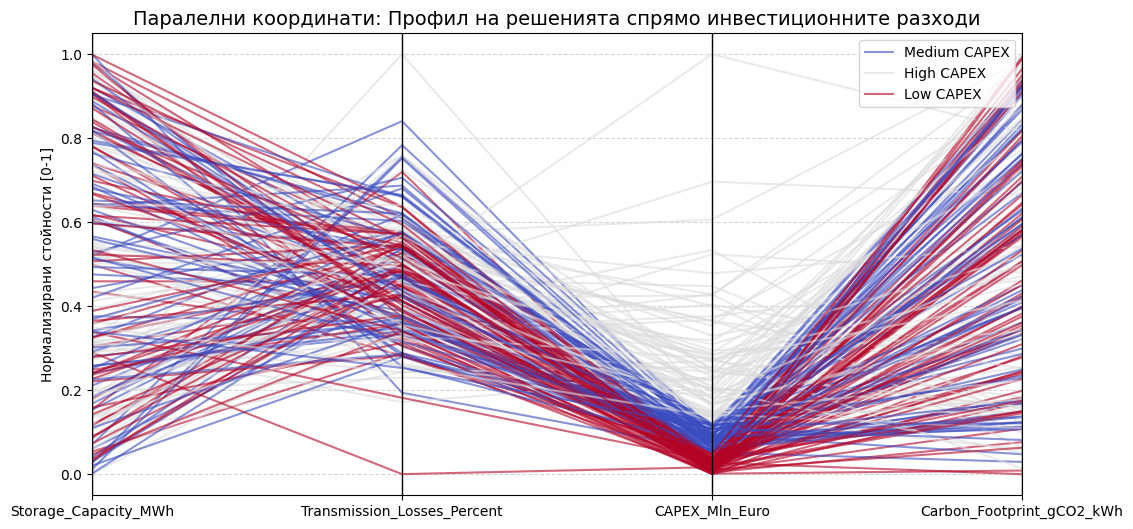

In [24]:
# ----------------------------------------------------
# ГРАФИКА 3: Parallel Coordinates Plot (Паралелни координати)
# ----------------------------------------------------
# Нормализираме данните само за тази графика, за да са в един мащаб (0 до 1)
df_norm = df_energy.copy()
criteria_cols = ['Storage_Capacity_MWh','Transmission_Losses_Percent', 'CAPEX_Mln_Euro', 'Carbon_Footprint_gCO2_kWh']
for col in criteria_cols:
  df_norm[col] = (df_energy[col] - df_energy[col].min()) / (df_energy[col].max() - df_energy[col].min())

plt.figure(figsize=(12, 6))
parallel_coordinates(df_norm[['Cost_Category'] + criteria_cols],
                     'Cost_Category',
                     colormap='coolwarm',
                     alpha=0.6)

plt.title('Паралелни координати: Профил на решенията спрямо инвестиционните разходи', fontsize=14)
plt.ylabel('Нормализирани стойности [0-1]')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# анализ на теглата


In [25]:
df_energy.columns

Index(['Configuration_ID', 'Storage_Capacity_MWh',
       'Transmission_Losses_Percent', 'CAPEX_Mln_Euro',
       'Carbon_Footprint_gCO2_kWh', 'Cost_Category'],
      dtype='object')

In [26]:
# ---  ПОДГОТОВКА И ОПТИМИЗАЦИЯ ---

# 1. Нормализация (Съгласно изискването в източника за интервал [4]) [5]
# Важно: За критерии като загуби, разходи и емисии, по-ниската стойност е по-добра.
# Затова ги нормализираме така, че 1 да е най-доброто (най-ниското), а 0 - най-лошото.
# --- НОРМАЛИЗАЦИЯ (Задължителна стъпка съгласно методологията) ---
df_norm = pd.DataFrame()
df_norm['Config_ID'] = df_energy['Configuration_ID']

# Капацитет: Колкото повече, толкова по-добре (директна нормализация)
df_norm['n_Capacity'] = (df_energy['Storage_Capacity_MWh'] - df_energy['Storage_Capacity_MWh'].min()) / \
                        (df_energy['Storage_Capacity_MWh'].max() - df_energy['Storage_Capacity_MWh'].min())

# Загуби, CAPEX и Емисии: Колкото по-малко, толкова по-добре (инверсна нормализация)
for col, new_col in zip(['Transmission_Losses_Percent', 'CAPEX_Mln_Euro', 'Carbon_Footprint_gCO2_kWh'],
                         ['n_Losses', 'n_CAPEX', 'n_Carbon']):
    df_norm[new_col] = (df_energy[col].max() - df_energy[col]) / (df_energy[col].max() - df_energy[col].min())

criteria_cols = ['n_Capacity', 'n_Losses', 'n_CAPEX', 'n_Carbon']





In [27]:
# --- 3.2 СЛУЧАЙ 1: ЛОКАЛЕН АНАЛИЗ (Фиксирани коефициенти) [1, 2] ---
# Задаваме експертни тегла, които се сумират до 1 [5]
fixed_weights = np.array([0.4, 0.2, 0.2, 0.2]) # Приоритет на капацитета

def get_score(row, weights):
    return np.dot(row[criteria_cols], weights)

df_norm['Local_Score'] = df_norm.apply(get_score, axis=1, args=(fixed_weights,))
best_local = df_norm.loc[df_norm['Local_Score'].idxmax()]

print(f"--- Локален анализ (Фиксирани тегла: {fixed_weights}) ---")
print(f"Най-добра конфигурация: {best_local['Config_ID']} със завидни показатели и резултат {best_local['Local_Score']:.3f}\n")

--- Локален анализ (Фиксирани тегла: [0.4 0.2 0.2 0.2]) ---
Най-добра конфигурация: Config_70 със завидни показатели и резултат 0.914



In [28]:
# --- 3.3 СЛУЧАЙ 2: ГЛОБАЛЕН АНАЛИЗ (Смяна на коефициентите) [1, 2] ---
# Ще анализираме как се променя най-доброто решение според важността на CAPEX (инвестиционните разходи)

def classify_importance(weight):
    if weight <= 0.33: return 'Ниска важност (0-33%)'
    elif weight <= 0.66: return 'Средна важност (33-66%)'
    else: return 'Висока важност (>66%)'

num_simulations = 1000
global_results = []

for _ in range(num_simulations):
    # Генериране на случайни тегла, чиято сума е 1 (разпределение на Дирихле)
    weights = np.random.dirichlet(np.ones(len(criteria_cols)))

    # Изчисляване на резултати за всички конфигурации с новите тегла
    scores = np.dot(df_norm[criteria_cols].values, weights)
    best_idx = np.argmax(scores)

    global_results.append({
        'CAPEX_Weight': weights[2], # Теглото на CAPEX е на индекс 2
        'Importance': classify_importance(weights[2]),
        'Best_Config': df_norm.iloc[best_idx]['Config_ID'],
        'Max_Score': scores[best_idx]
    })

df_global = pd.DataFrame(global_results)

# Анализ на 3-те групи по важност
summary = df_global.groupby('Importance').agg({
    'Max_Score': 'mean',
    'Best_Config': lambda x: x.value_counts().index # Най-честият победител в групата
}).rename(columns={'Best_Config': 'Top_Frequent_Winner', 'Max_Score': 'Avg_Max_Score'})

print("--- Глобален анализ (Вариращи тегла и групиране по важност на CAPEX) ---")
print(summary)

--- Глобален анализ (Вариращи тегла и групиране по важност на CAPEX) ---
                         Avg_Max_Score  \
Importance                               
Висока важност (>66%)         0.953025   
Ниска важност (0-33%)         0.909359   
Средна важност (33-66%)       0.928883   

                                                       Top_Frequent_Winner  
Importance                                                                  
Висока важност (>66%)    [Config_111, Config_189, Config_199, Config_19...  
Ниска важност (0-33%)    [Config_70, Config_113, Config_111, Config_53,...  
Средна важност (33-66%)  [Config_70, Config_189, Config_111, Config_113...  


# локален анализ

In [31]:
import numpy as np
import pandas as pd

# 1. Фиксиране на теглата (Локален аспект - Задача 3)
# Използваме теглата от предходния пример, но ги фиксираме
fixed_weights = np.array([0.4, 0.2, 0.2, 0.2]) # Capacity, Losses, CAPEX, Carbon
criteria_cols = ['n_Capacity', 'n_Losses', 'n_CAPEX', 'n_Carbon']

# 2. Симулация на промени в данните (Data Sensitivity)
# Ще генерираме 1000 сценария, в които леко променяме стойностите на индикаторите
# за да видим дали "победителят" остава същият.
num_data_scenarios = 1000
data_stability_results = []

# Изходна точка: нашата нормализирана матрица df_norm
base_data = df_norm[criteria_cols].values
config_ids = df_norm['Config_ID'].values

for i in range(num_data_scenarios):
    # Добавяме малък случаен "шум" към данните (симулираме промяна в измерванията/обстоятелствата)
    # Шумът е в рамките на +/- 5%
    noise = np.random.uniform(-0.05, 0.05, size=base_data.shape)
    varied_data = np.clip(base_data + noise, 0, 1) # Гарантираме интервала [3] [4]

    # Изчисляваме резултатите с ФИКСИРАНИ тегла
    scores = np.dot(varied_data, fixed_weights)
    best_idx = np.argmax(scores)

    data_stability_results.append({
        'Scenario_ID': i,
        'Best_Config': config_ids[best_idx],
        'Max_Score': scores[best_idx]
    })

df_data_analysis = pd.DataFrame(data_stability_results)

# 3. Анализ на честотата (Устойчивост на решението)
stability_summary = df_data_analysis['Best_Config'].value_counts(normalize=True) * 100

print("--- Локален анализ: Устойчивост при фиксирани тегла и вариращи данни ---")
print(f"Фиксирани тегла: {fixed_weights}")
print("\nКолко често дадена конфигурация остава №1 при промяна в данните (%):")
print(stability_summary.head())

--- Локален анализ: Устойчивост при фиксирани тегла и вариращи данни ---
Фиксирани тегла: [0.4 0.2 0.2 0.2]

Колко често дадена конфигурация остава №1 при промяна в данните (%):
Best_Config
Config_70     82.0
Config_53     14.7
Config_113     3.3
Name: proportion, dtype: float64


# 5)  Интегриран аналитичен модел

Намерени Парето-оптимални конфигурации: 34

Профили на откритите класове (Средни стойности):
         Storage_Capacity_MWh  Transmission_Losses_Percent  CAPEX_Mln_Euro  \
Cluster                                                                      
0                   49.814594                     8.284438        7.235308   
1                   48.872247                     7.961118        6.941051   
2                  119.504152                     8.150537        6.254946   

         Carbon_Footprint_gCO2_kWh  
Cluster                             
0                       321.491669  
1                       104.160611  
2                       198.062853  


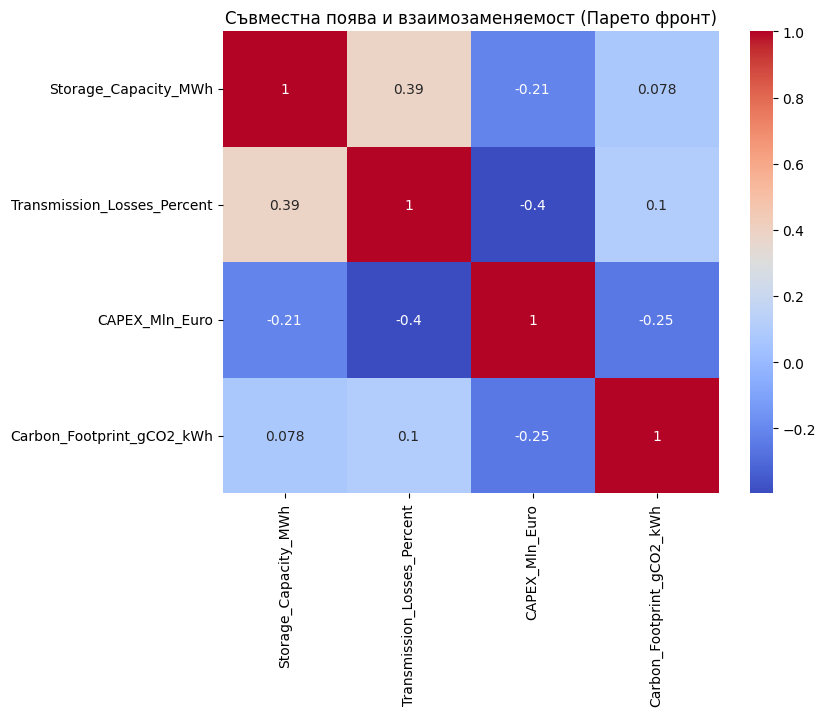

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# --- 1. ПАРЕТО АНАЛИЗ (Идентифициране на недоминирани решения) ---
def get_pareto_frontier(costs):
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            # Решението е ефективно, ако не е доминирано от други
            is_efficient[is_efficient] = np.any(costs[is_efficient] > c, axis=1) | \
                                         np.all(costs[is_efficient] == c, axis=1)
    return is_efficient

# Използваме нормализираните данни (0-1), където 1 е най-добро [5]
data_matrix = df_norm[['n_Capacity', 'n_Losses', 'n_CAPEX', 'n_Carbon']].values
df_energy['Is_Pareto'] = get_pareto_frontier(data_matrix)

# --- 2. КЛЪСТЕРИЗАЦИЯ И КЛАСИФИКАЦИЯ (Задача 5) ---
# Използваме K-Means за обособяване на 3 класа конфигурации (напр. Ефективни, Балансирани, Рискови)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_energy['Cluster'] = kmeans.fit_predict(data_matrix)

# --- 3. ПРОФИЛИРАНЕ НА КЛАСОВЕТЕ ---
# Изчисляваме средните стойности на индикаторите за всеки клъстер
profiles = df_energy.groupby('Cluster')[['Storage_Capacity_MWh', 'Transmission_Losses_Percent',
                                         'CAPEX_Mln_Euro', 'Carbon_Footprint_gCO2_kWh']].mean()

# --- 4. ЧЕСТОТА И СЪВМЕСТНА ПОЯВА НА ИНДИКАТОРИ ---
# Анализираме корелацията при Парето-оптималните решения (взаимозаменяемост)
pareto_data = df_energy[df_energy['Is_Pareto'] == True]
co_occurrence = pareto_data[['Storage_Capacity_MWh', 'Transmission_Losses_Percent',
                             'CAPEX_Mln_Euro', 'Carbon_Footprint_gCO2_kWh']].corr()

# --- 5. ВИЗУАЛИЗАЦИЯ И ИНТЕРПРЕТАЦИЯ (Задача 7) ---
print(f"Намерени Парето-оптимални конфигурации: {df_energy['Is_Pareto'].sum()}")
print("\nПрофили на откритите класове (Средни стойности):")
print(profiles)

# Визуализация на съвместната поява (Correlation Heatmap)
plt.figure(figsize=(8,6))
sns.heatmap(co_occurrence, annot=True, cmap='coolwarm')
plt.title("Съвместна поява и взаимозаменяемост (Парето фронт)")
plt.show()